In [1]:
!nvidia-smi

Mon Apr 13 12:51:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   31C    P8              7W /  180W |     720MiB /  16311MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Dataset
- download
- preprocess

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("matthewjansen/ucf101-action-recognition")

print("Path to dataset files:", path)

In [ ]:
path = ''

In [6]:
import os
import cv2
import torch
import random
import shutil
import numpy as np
from tqdm import tqdm
from torchvision import transforms

# -----------------------------
# CONFIGURATION
# -----------------------------

FRAME_RATE = 25            # Target frame rate
CLIP_LEN = 16              # Number of frames per clip
RESIZE_HEIGHT = 224
CROP_SIZE = 224
TRAIN_SPLIT = 0.8           # 80% train, 20% test
SEED = 42

random.seed(SEED)

# -----------------------------
# TRANSFORMS (spatial only)
# -----------------------------
spatial_transform = transforms.Compose([
    transforms.Resize((RESIZE_HEIGHT, RESIZE_HEIGHT)),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# -----------------------------
# UTILITY FUNCTIONS
# -----------------------------
def extract_frames(video_path, target_fps=FRAME_RATE):
    """
    Extract frames from a video at target fps.
    Returns a list of PIL tensors.
    """
    cap = cv2.VideoCapture(video_path)
    original_fps = cap.get(cv2.CAP_PROP_FPS)
    if original_fps <= 0:
        original_fps = target_fps

    frame_interval = max(int(original_fps // target_fps), 1)

    frames = []
    count = 0
    success, frame = cap.read()

    while success:
        if count % frame_interval == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
        success, frame = cap.read()
        count += 1

    cap.release()
    return frames

def temporal_sample(frames, clip_len=CLIP_LEN):
    """
    Sample a fixed-length clip (clip_len) from the video frames.
    If video has fewer frames than clip_len, repeat last frame.
    """
    num_frames = len(frames)

    if num_frames >= clip_len:
        start = random.randint(0, num_frames - clip_len)
        return frames[start:start + clip_len]
    else:
        # Pad with last frame if not enough frames
        last_frame = frames[-1]
        while len(frames) < clip_len:
            frames.append(last_frame)
        return frames

from PIL import Image

def save_clip_tensor(frames, output_path):
    """
    Apply spatial transforms and save the clip as a PyTorch tensor.
    """
    processed_frames = [
        spatial_transform(Image.fromarray(frame))  # <-- Convert to PIL here
        for frame in frames
    ]
    clip_tensor = torch.stack(processed_frames, dim=0)  # Shape: [T, C, H, W]
    torch.save(clip_tensor, output_path)


# -----------------------------
# MAIN PREPROCESSING
# -----------------------------
def preprocess_dataset(selected_classes, output_root, reset_output=False):
    print(f"Preprocessing UCF101 ({len(selected_classes)} classes) from {DATASET_ROOT} -> {output_root}")

    if reset_output and os.path.exists(output_root):
        shutil.rmtree(output_root)

    os.makedirs(output_root, exist_ok=True)

    for split_name in ["train", "val", "test"]:
        print(f"\nProcessing split: {split_name}")
        split_input_path = os.path.join(DATASET_ROOT, split_name)
        split_output_path = os.path.join(output_root, split_name)
        os.makedirs(split_output_path, exist_ok=True)

        for cls in selected_classes:
            class_input_path = os.path.join(split_input_path, cls)
            if not os.path.isdir(class_input_path):
                print(f"Warning: Class {cls} not found in {split_name}, skipping.")
                continue

            class_output_path = os.path.join(split_output_path, cls)
            os.makedirs(class_output_path, exist_ok=True)

            print(f"\n  Class: {cls}")
            videos = [
                os.path.join(class_input_path, v)
                for v in os.listdir(class_input_path)
                if v.endswith(".avi")
            ]
            videos.sort()

            for vid_path in tqdm(videos, desc=f"{cls} [{split_name}]"):
                frames = extract_frames(vid_path)
                if len(frames) == 0:
                    print(f"Skipping empty video: {vid_path}")
                    continue

                sampled_frames = temporal_sample(frames)
                video_name = os.path.splitext(os.path.basename(vid_path))[0]
                output_clip = os.path.join(class_output_path, f"{video_name}.pt")

                if os.path.exists(output_clip):
                    continue

                save_clip_tensor(sampled_frames, output_clip)

    print("\nPreprocessing completed successfully!")
    print(f"Processed data saved at: {output_root}")


In [22]:
DATASET_ROOT = path
OUTPUT_ROOT = "./UCF101/processed_data"

SELECTED_CLASSES = ["PlayingTabla","PommelHorse","JumpingJack","PushUps","PoleVault","HorseRace","HighJump","Drumming","HorseRiding","Diving","BreastStroke",
              "TrampolineJumping","YoYo","SalsaSpin","WalkingWithDog","VolleyballSpiking","ThrowDiscus","TennisSwing","TaiChi","Swing",
              "SoccerJuggling","Skijet","Skiing","SkateBoarding","Rowing","RopeClimbing","RockClimbingIndoor","Punch","PullUps","PlayingViolin","PlayingPiano","PlayingGuitar",
              "HulaHoop","GolfSwing","Fencing","CleanAndJerk","Billiards","Biking","BenchPress","BaseballPitch"]


In [23]:
preprocess_dataset(selected_classes=SELECTED_CLASSES,
                   output_root=OUTPUT_ROOT,
                   reset_output=True)

Preprocessing UCF101 (40 classes) from C:\Users\guzun\.cache\kagglehub\datasets\matthewjansen\ucf101-action-recognition\versions\4 -> ./UCF101/processed_data

Processing split: train

  Class: PlayingTabla


PlayingTabla [train]: 100%|██████████| 83/83 [00:05<00:00, 16.41it/s]



  Class: PommelHorse


PommelHorse [train]: 100%|██████████| 92/92 [00:05<00:00, 16.54it/s]



  Class: JumpingJack


...


  Class: BenchPress


BenchPress [test]: 100%|██████████| 20/20 [00:00<00:00, 25.00it/s]



  Class: BaseballPitch


BaseballPitch [test]: 100%|██████████| 19/19 [00:00<00:00, 26.45it/s]


Preprocessing completed successfully!
Processed data saved at: ./UCF101/processed_data


# DATASET and DATALOADER

In [1]:
from torch.utils.data import Dataset
import torch
import os
from glob import glob

class UCF101Clips(Dataset):
    def __init__(self, root_dir, split="train", class_names=None, class_to_idx=None):
        self.root = os.path.join(root_dir, split)

        if class_names is None:
            class_names = sorted(
                [d for d in os.listdir(self.root) if os.path.isdir(os.path.join(self.root, d))]
            )

        self.classes = class_names

        if class_to_idx is None:
            class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.class_to_idx = class_to_idx
        self.samples = []

        for cls_name in self.classes:
            class_dir = os.path.join(self.root, cls_name)
            if not os.path.isdir(class_dir):
                continue

            clips = glob(os.path.join(class_dir, "*.pt"))
            cls_idx = self.class_to_idx[cls_name]

            for clip in clips:
                self.samples.append((clip, cls_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = torch.load(path)
        return clip, label


In [2]:
def class_to_idx_mapping(class_names):
    "Utility function to create class name to index mapping."
    return {cls_name: i for i, cls_name in enumerate(class_names)}

In [3]:
DATASET_ROOT = "./ucf101-action-recognition/versions/4"
OUTPUT_ROOT = "./UCF101/processed_data"

SELECTED_CLASSES = ["PlayingTabla","PommelHorse","JumpingJack","PushUps","PoleVault","HorseRace","HighJump","Drumming","HorseRiding","Diving","BreastStroke",
              "TrampolineJumping","YoYo","SalsaSpin","WalkingWithDog","VolleyballSpiking","ThrowDiscus","TennisSwing","TaiChi","Swing",
              "SoccerJuggling","Skijet","Skiing","SkateBoarding","Rowing","RopeClimbing","RockClimbingIndoor","Punch","PullUps","PlayingViolin","PlayingPiano","PlayingGuitar",
              "HulaHoop","GolfSwing","Fencing","CleanAndJerk","Billiards","Biking","BenchPress","BaseballPitch"]


In [4]:
len(SELECTED_CLASSES)

40

In [5]:
os.listdir(OUTPUT_ROOT)

['test', 'train', 'val']

In [6]:
train_dataset = UCF101Clips(root_dir=OUTPUT_ROOT, # folder where processed data is stored
            split="train",
            class_names=SELECTED_CLASSES,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES))

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4, )

test_dataset = UCF101Clips(root_dir=OUTPUT_ROOT,
            split="val",
            class_names=SELECTED_CLASSES,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES))

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0, )

val_dataset = UCF101Clips(root_dir=OUTPUT_ROOT,
            split="val",
            class_names=SELECTED_CLASSES,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES))

val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0,)

In [7]:
# Inspect one batch from train_loader
clips, labels = next(iter(train_loader))

print("Clips shape:", clips.shape)
print("Clips dtype:", clips.dtype)
print("Labels shape:", labels.shape)
print("Labels dtype:", labels.dtype)
print("Labels:", labels.tolist())
print("Unique labels in batch:", torch.unique(labels).tolist())

if clips.ndim == 5:
    print(f"Batch size: {clips.shape[0]}")
    print(f"Temporal length: {clips.shape[1]}")
    print(f"Channels: {clips.shape[2]}")
    print(f"Height: {clips.shape[3]}")
    print(f"Width: {clips.shape[4]}")


Clips shape: torch.Size([4, 16, 3, 224, 224])
Clips dtype: torch.float32
Labels shape: torch.Size([4])
Labels dtype: torch.int64
Labels: [7, 34, 37, 36]
Unique labels in batch: [7, 34, 36, 37]
Batch size: 4
Temporal length: 16
Channels: 3
Height: 224
Width: 224


# MODEL
1. ViT b 16

In [6]:
from torch.nn import LSTM
import torch
from torchvision import models


class vit_lstm(torch.nn.Module):
    def __init__(self, classes=2, name=str):
        super().__init__()
        self.classes = classes  # Number of output classes
        self.name = name

        if self.name == 'vit_b_16':
          self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
          self.vit.heads = torch.nn.Identity()  # Remove the classification head
          self.lstm = LSTM(input_size=768, hidden_size=256, num_layers=2, batch_first=True)

        self.classifier = torch.nn.Linear(256, self.classes)  # Classification layer

    def forward(self, x):
        # x: [B, T, 3, 224, 224]
        B, T, C, H, W = x.shape

        # Merge batch and time
        x = x.view(B*T, C, H, W)   # [B*T, 3, 224, 224]

        # Pass through ViT
        x = self.vit(x)            # [B*T, 768]

        # Reshape back to sequence
        x = x.view(B, T, -1)       # [B, T, 768]

        # LSTM
        x, _ = self.lstm(x)        # [B, T, 256]

        # Take last time step
        x = x[:, -1, :]            # [B, 256]

        # Classifier
        x = self.classifier(x)     # [B, classes]

        return x

In [7]:
# model loading
model_name = 'vit_b_16'

model = vit_lstm(classes=len(SELECTED_CLASSES), name=model_name)

print("Model initialized!")


Model initialized!


In [9]:
model

vit_lstm(
  (vit): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
    

# Model testing


In [8]:
# test function
# confusion matrix, accuracy, precision, recall, F1-score
# visualize confusion matrix using seaborn heatmap

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def test(model, test_loader, device='cuda'):
    model.to(device)
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
    # use tqdm to show progress bar
        print("Model : ", model.name)
        for clips, labels in tqdm.tqdm(test_loader, desc="Testing on test set"):
            clips = clips.to(device)
            labels = labels.to(device)

            outputs = model(clips)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute metrics

    cm = confusion_matrix(all_labels, all_preds)


    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=SELECTED_CLASSES,
                yticklabels=SELECTED_CLASSES)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    # add accuracy, precision, recall, F1-score to the output
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")



DEVICE:  cuda
Model :  vit_b_16


Testing on test set: 100%|██████████| 81/81 [00:46<00:00,  1.74it/s]


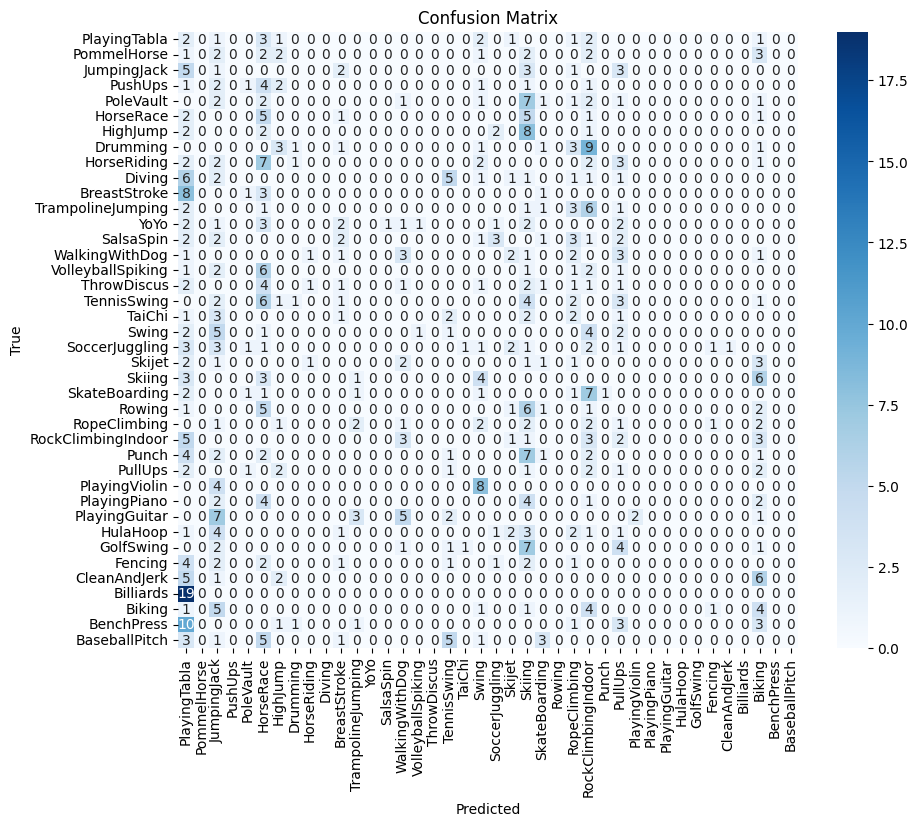

Accuracy: 0.0310
Precision: 0.0182
Recall: 0.0310
F1-score: 0.0171


c:\Users\guzun\miniconda3\envs\apai\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
if torch.cuda.is_available():
    device = 'cuda'
print("DEVICE: ", device)
test(model, test_loader, device=device)

# Train Model
- Finetune

In [9]:
from matplotlib import pyplot as plt
def accuracy_curve(train_accuracies, val_accuracies):
    plt.figure(figsize=(10, 5))
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Curve')
    plt.legend()
    plt.grid()
    plt.show()

def loss_curve(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curve')
    plt.legend()
    plt.grid()
    plt.show()

In [14]:
# train function
# plot loss curve for train and validation
# plot accuracy curve
# during evaluation use the previous test function to compute metrics and visualize confusion matrix
# save the model at the end of each epoch

from matplotlib import pyplot as plt
import torch
import tqdm

def fine_tune(model, train_loader, val_loader, test_loader, device='cuda', epochs=10, lr=1e-4):
    model.to(device)
    

    if model.name == 'vit_b_16':
        for param in model.vit.parameters():
            param.requires_grad = False

        for i, block in enumerate(model.vit.encoder.layers):
            if i >= 10 and model.name == 'vit_b_16':
                for param in block.parameters(): param.requires_grad = True
    
    for param in model.lstm.parameters(): param.requires_grad = True
    
    for param in model.classifier.parameters(): param.requires_grad = True

    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        correct = 0
        total = 0
        for clips, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training"):
            clips = clips.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(clips)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        train_loss = epoch_loss / len(train_loader)
        train_accuracy = correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for clips, labels in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} - Validation"):
                clips = clips.to(device)
                labels = labels.to(device)

                outputs = model(clips)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                predicted = torch.argmax(outputs, dim=1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        val_loss /= len(val_loader)
        val_accuracy = correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        print(f"Epoch {epoch+1}/{epochs} - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")   

    accuracy_curve(train_accuracies, val_accuracies)
    loss_curve(train_losses, val_losses)


        # Save model
    torch.save(model.state_dict(), f"{model.name}_epoch_{epoch+1}.pth.tar")
    print(f"Model saved: {model.name}_epoch_{epoch+1}.pth.tar")



In [11]:
train_dataset = UCF101Clips(root_dir=OUTPUT_ROOT, # folder where processed data is stored
            split="train",
            class_names=SELECTED_CLASSES,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES))

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True, )

test_dataset = UCF101Clips(root_dir=OUTPUT_ROOT,
            split="val",
            class_names=SELECTED_CLASSES,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES))

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False, )

val_dataset = UCF101Clips(root_dir=OUTPUT_ROOT,
            split="val",
            class_names=SELECTED_CLASSES,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES))

val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=8, shuffle=False, )

Starting fine-tuning...
Device : cuda


Epoch 1/10 - Training: 100%|██████████| 485/485 [07:01<00:00,  1.15it/s]


Epoch 1/10 - Train Loss: 1.9805, Train Accuracy: 0.6773


Epoch 1/10 - Validation: 100%|██████████| 81/81 [00:42<00:00,  1.90it/s]


Epoch 1/10 - Val Loss: 0.6793, Val Accuracy: 0.9085


...

Epoch 9/10 - Val Loss: 0.1049, Val Accuracy: 0.9721


Epoch 10/10 - Training: 100%|██████████| 485/485 [06:35<00:00,  1.23it/s]


Epoch 10/10 - Train Loss: 0.0039, Train Accuracy: 1.0000


Epoch 10/10 - Validation: 100%|██████████| 81/81 [00:42<00:00,  1.91it/s]

Epoch 10/10 - Val Loss: 0.1023, Val Accuracy: 0.9736


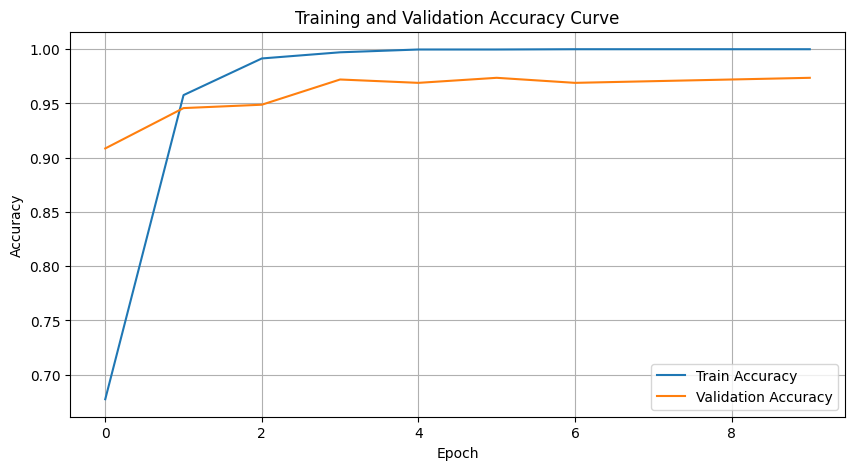

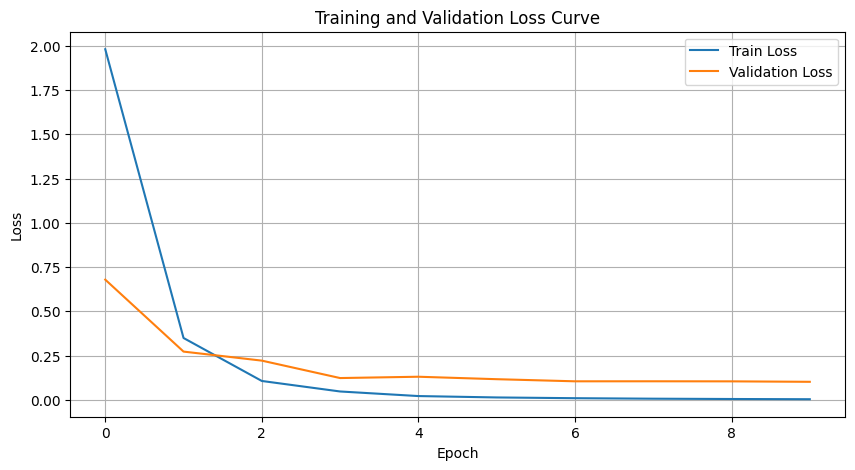

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print("Starting fine-tuning...")
print(f'Device : {device}')
fine_tune(model, train_loader, val_loader, test_loader, device=device, epochs=10, lr=5e-5)

Model :  vit_b_16


Testing on test set: 100%|██████████| 81/81 [00:40<00:00,  1.98it/s]


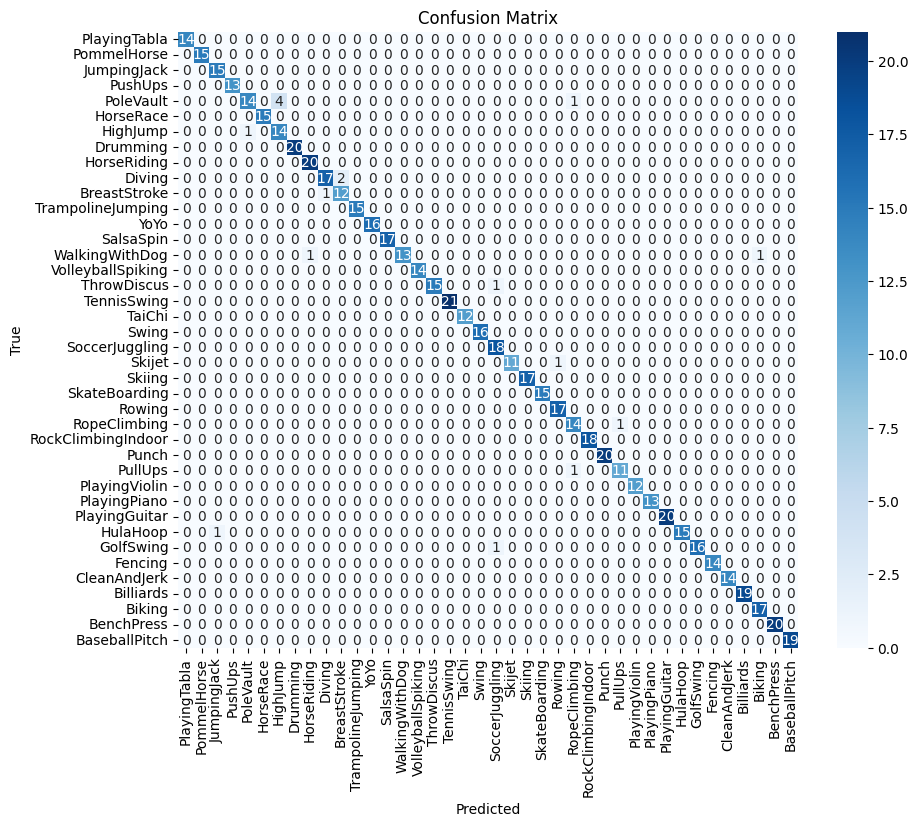

Accuracy: 0.9736
Precision: 0.9752
Recall: 0.9736
F1-score: 0.9735


In [13]:
test(model=model, test_loader=test_loader, device=device)